# Discontinuous Galerkin Method for 1D Scalar Conservation Laws

A Python implementation of the Discontinuous Galerkin (DG) method for solving one-dimensional scalar hyperbolic conservation laws.

**Reference:** Shu, Chi-Wang. "Discontinuous Galerkin Methods: General Approach and Stability." (2008).

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import legendre
import pandas as pd

plt.rcParams.update(
    {
        "savefig.dpi": 300,
        "figure.autolayout": True,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "lines.linewidth": 1.0,
        "lines.markersize": 5,
        "axes.linewidth": 1.0,
        "lines.markerfacecolor": "none",
        "lines.markeredgecolor": "auto",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.framealpha": 1.0,
    }
)

## 1. Burgers Equation

Consider the scalar conservation law
$$u_t + f(u)_x = 0$$

with the flux function $f(u) = \frac{u^2}{2}$, which yields the inviscid Burgers equation:
$$u_t + \left(\frac{1}{2}u^2\right)_x = 0$$

### Method of Characteristics

For the Burgers equation, the characteristic line passing through point $(\xi, 0)$ is given by
$$x = \xi + u_0(\xi)t$$

The solution $u$ remains constant along this characteristic line: $u(x,t) = u_0(\xi)$.

**Solution construction:**

- If a unique characteristic line passes through $(x,t)$, then $u(x,t) = u_0(\xi)$ where $\xi$ is the unique root of the nonlinear equation (solved via Newton's method):
  $$G(u) = u - u_0(x - ut) = 0$$
- If multiple characteristic lines pass through $(x,t)$, the equation has multiple roots, but only one corresponds to the physical solution. A suitable initial guess is required.
- If no characteristic line passes through $(x,t)$, the equation has no solution—this corresponds to a rarefaction wave region.

### Sine Wave Initial Condition

Consider the periodic initial condition:
$$\begin{aligned}
u_t + \left(\frac{u^2}{2}\right)_x &= 0, \quad x \in [x_l, x_r] \\
u(x,0) &= \alpha + \beta \sin(wx + \phi), \quad w = \frac{2\pi}{x_r - x_l}, \beta > 0
\end{aligned}$$

The solution takes the form:
$$u(x,t) = \alpha + \beta \,\widetilde{u}(wx + \phi - \alpha w t, \beta w t)$$

where $\widetilde{u}$ solves the sine-wave problem on $[-\pi, \pi]$:
$$\begin{aligned}
\widetilde{u}_t + \left(\frac{\widetilde{u}^2}{2}\right)_x &= 0 \\
\widetilde{u}(x,0) &= \sin(x)
\end{aligned}$$

For this problem, the nonlinear equation becomes:
$$G(u) = u - \sin(x - ut)$$

Newton's iteration:
$$u^{(n+1)} = u^{(n)} - \frac{G(u^{(n)})}{G'(u^{(n)})} = u^{(n)} - \frac{u^{(n)} - \sin(x - u^{(n)}t)}{1 + \cos(x - u^{(n)}t)t}$$

A suitable initial guess is:
$$u^{(0)} = \frac{x}{\pi/2 + t}, \quad x \in [-\pi, \pi]$$

In [25]:
def burgers_f(u):
    """Flux function f(u) = u^2/2"""
    return u**2 / 2


def burgers_df(u):
    """Flux derivative f'(u) = u"""
    return u

In [26]:
def burgers_sin_solver_kernel(x, t):
    """
    Solve the sine-wave initial value problem for Burgers equation.

    Parameters
    ----------
    x : array
        Spatial coordinates in [-pi, pi]
    t : float
        Time

    Returns
    -------
    u : array
        Solution u(x,t) = sin(x - u*t)
    """
    u = x / (np.pi / 2 + t)  # initial guess

    # Newton iteration
    for _ in range(100000):
        du = (u - np.sin(x - u * t)) / (1 + np.cos(x - u * t) * t)
        u = u - du

        if np.max(np.abs(du)) < 1e-10:
            break

    return u


def burgers_sin_solver(x, t, a, b, w, phi):
    """
    Solve Burgers equation with sinusoidal initial condition.

    u(x,0) = a + b*sin(w*x + phi)

    Parameters
    ----------
    x : array
        Spatial coordinates
    t : float
        Time
    a : float
        Mean value
    b : float
        Amplitude
    w : float
        Angular frequency
    phi : float
        Phase shift

    Returns
    -------
    u : array
        Solution at (x,t)
    """
    x_tilde = w * x + phi - a * w * t
    x_tilde = np.mod(x_tilde + np.pi, 2 * np.pi) - np.pi  # map to [-pi, pi]
    t_tilde = b * w * t

    return a + b * burgers_sin_solver_kernel(x_tilde, t_tilde)

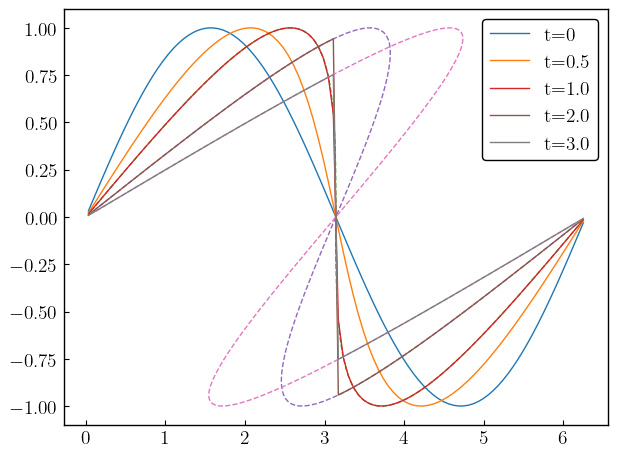

In [27]:
fig, ax = plt.subplots()

for tend in [0, 0.5, 1.0, 2.0, 3.0]:
    x, dx = np.linspace(0, 2 * np.pi, 100, endpoint=False, retstep=True)
    x += dx / 2

    u = burgers_sin_solver(x, tend, a=0.0, b=1.0, w=1.0, phi=0)

    if tend >= 1.0:
        u0 = lambda s: np.sin(s)
        ax.plot(x + u0(x) * tend, u0(x), "--")

    ax.plot(x, u, label=f"t={tend}")

ax.legend()

## 2. Time Integration: SSP-RK3

For the ODE problem $u_t = L(u, t)$, the Strong Stability Preserving (SSP) Runge-Kutta method of order 3 is given by:

$$\begin{aligned}
u^{(1)} &= u^n + \Delta t\, L(u^n, t^n) \\
u^{(2)} &= \frac{3}{4}u^n + \frac{1}{4}\left(u^{(1)} + \Delta t\, L(u^{(1)}, t^n + \Delta t)\right) \\
u^{n+1} &= \frac{1}{3}u^n + \frac{2}{3}\left(u^{(2)} + \Delta t\, L(u^{(2)}, t^n + \frac{\Delta t}{2})\right)
\end{aligned}$$

When a post-processing operator is applied after each stage (e.g., for limiters):

$$\begin{aligned}
u^{(1)} &= P\left(u^n + \Delta t\, L(u^n, t^n)\right) \\
u^{(2)} &= P\left(\frac{3}{4}u^n + \frac{1}{4}\left(u^{(1)} + \Delta t\, L(u^{(1)}, t^n + \Delta t)\right)\right) \\
u^{n+1} &= P\left(\frac{1}{3}u^n + \frac{2}{3}\left(u^{(2)} + \Delta t\, L(u^{(2)}, t^n + \frac{\Delta t}{2})\right)\right)
\end{aligned}$$

In [28]:
def SSP_RK3_with_post_process(u, t, dt, op_L, post_process, **kwargs):
    """
    SSP-RK3 time stepping with optional post-processing.

    Parameters
    ----------
    u : array
        Current solution
    t : float
        Current time
    dt : float
        Time step
    op_L : callable
        Spatial operator L(u, t)
    post_process : callable
        Post-processing operator (e.g., limiter)

    Returns
    -------
    unew : array
        Solution at next time level
    """
    u1_pre = u + dt * op_L(u, t, **kwargs)
    u1 = post_process(u1_pre)
    u2_pre = 3 / 4 * u + 1 / 4 * (u1 + dt * op_L(u1, t + dt, **kwargs))
    u2 = post_process(u2_pre)
    unew_pre = 1 / 3 * u + 2 / 3 * (u2 + dt * op_L(u2, t + dt / 2, **kwargs))
    unew = post_process(unew_pre)

    return unew

## 3. Numerical Flux: Lax-Friedrichs

The Lax-Friedrichs (LF) numerical flux is given by:
$$f^{LF}(u^-, u^+) = \frac{1}{2}\left(f(u^-) + f(u^+)\right) - \frac{\alpha}{2}(u^+ - u^-)$$

where $\alpha = \max |f'(u)|$ is the maximum wave speed.

For Burgers equation $f(u) = u^2/2$, we have $f'(u) = u$. Since $f'$ is monotonic, the local wave speed is:
$$\alpha = \max(|u^-|, |u^+|)$$

In [29]:
def get_LF_flux(f, get_alpha):
    """
    Create Lax-Friedrichs numerical flux function.

    Parameters
    ----------
    f : callable
        Physical flux function
    get_alpha : callable
        Function to compute maximum wave speed

    Returns
    -------
    fhat_lf : callable
        Numerical flux function
    """
    def fhat_lf(ul, ur):
        return (f(ul) + f(ur)) / 2 - get_alpha(ul, ur) / 2 * (ur - ul)

    return fhat_lf


def burgers_get_alpha(ul, ur):
    """Maximum wave speed for Burgers equation."""
    return np.maximum(np.abs(burgers_df(ul)), np.abs(burgers_df(ur)))

## 4. Gaussian Quadrature

Gaussian quadrature on the standard interval $[-1, 1]$:
$$\int_{-1}^1 g(\xi)\,d\xi \approx \sum_{i=1}^{k_g} w_i g(\xi_i)$$

where $\{\xi_i\}$ are quadrature nodes and $\{w_i\}$ are corresponding weights.

For a general interval $[x_l, x_r]$, using the change of variables $x = \frac{x_l + x_r}{2} + \frac{x_r - x_l}{2}\xi$:
$$\int_{x_l}^{x_r} f(x)\,dx \approx \frac{x_r-x_l}{2} \sum_{i=1}^{k_g} w_i f(x_i),\quad x_i = \frac{x_l + x_r}{2} + \frac{x_r - x_l}{2} \xi_i$$

In [30]:
def gauss_quadrature(f, xl, xr, gk):
    """
    Compute integral using Gaussian quadrature.

    Parameters
    ----------
    f : callable
        Function to integrate
    xl, xr : float
        Integration interval
    gk : int
        Number of quadrature points

    Returns
    -------
    result : float or array
        Integral value
    """
    x = (xl + xr) / 2
    dx = xr - xl

    scalar_flag = np.isscalar(x)
    x = np.atleast_1d(x)  # shape = (n,)

    points, weights = legendre.leggauss(gk)  # shape = (gk,), (gk,)

    # shape = (n, np.newaxis) + (gk,) = (n, gk)
    x_nodes = x[:, np.newaxis] + dx / 2 * points
    # shape = (n, gk) * (gk,) = (n, gk)
    integral_values = f(x_nodes) * weights
    result = dx / 2 * np.sum(integral_values, axis=1)  # shape = (n,)

    return result if not scalar_flag else result[0]  # shape = (n,) or scalar

## 5. Legendre Basis Functions

Let $p_0, p_1, \dots, p_k$ denote the Legendre polynomials on $[-1, 1]$:
$$p_0(\xi) = 1, \quad p_1(\xi) = \xi, \quad p_2(\xi) = \frac{1}{2}(3\xi^2 - 1), \quad \dots$$

For a single point $\xi \in [-1, 1]$, the basis function values form a vector:
$$[p_0(\xi), p_1(\xi), \dots, p_k(\xi)]^T \in \mathbb{R}^{k+1}$$

For points $\vec{\xi} \in [-1, 1]^n$, the basis matrix is:
$$M = \begin{bmatrix}
p_0(\xi_1) & p_0(\xi_2) & \cdots & p_0(\xi_n) \\ 
p_1(\xi_1) & p_1(\xi_2) & \cdots & p_1(\xi_n) \\  
\vdots & \vdots & \ddots & \vdots \\
p_k(\xi_1) & p_k(\xi_2) & \cdots & p_k(\xi_n)   
\end{bmatrix} \in \mathbb{R}^{(k+1) \times n}$$

In [31]:
def basis_eval(k, points):
    """
    Evaluate Legendre basis functions.

    Parameters
    ----------
    k : int
        Polynomial degree
    points : array
        Points in [-1, 1]

    Returns
    -------
    result : array
        Shape (k+1, len(points)) or (k+1,) if scalar
    """
    scalar_flag = np.isscalar(points)
    points = np.atleast_1d(points)

    coeff = np.identity(k + 1)
    result = np.zeros((k + 1, len(points)))

    for i in range(k + 1):
        result[i] = legendre.Legendre(coeff[i])(points)

    # shape = (k+1, len(points)) or (k+1,)
    return result[:, 0] if scalar_flag else result

## 6. Basis Function Derivatives

The derivatives $p'_0(\xi), p'_1(\xi), \dots, p'_k(\xi)$ are also needed.

For a single point $\xi$, the derivative vector is:
$$[p'_0(\xi), p'_1(\xi), \dots, p'_k(\xi)]^T \in \mathbb{R}^{k+1}$$

The recurrence relation for Legendre polynomial derivatives:
$$p'_n(\xi) = \frac{n}{\xi^2 - 1}(p_n(\xi) - p_{n-1}(\xi)), \quad n \geq 1$$

**Note:** This formula is not valid at endpoints $\xi = \pm 1$.

For transformation to physical coordinates $x$:
$$\partial_x p_i\left(\frac{x - x_j}{h/2}\right) = \frac{2}{h} p'_i\left(\frac{x - x_j}{h/2}\right)$$

In [32]:
def basis_dx_eval(k, points):
    """
    Evaluate derivatives of Legendre basis functions.

    Parameters
    ----------
    k : int
        Polynomial degree
    points : array
        Points in [-1, 1]

    Returns
    -------
    result : array
        Shape (k+1, len(points)) or (k+1,) if scalar
    """
    scalar_flag = np.isscalar(points)
    points = np.atleast_1d(points)

    coeff = np.identity(k + 1)
    result = np.zeros((k + 1, len(points)))

    for i in range(1, k + 1):
        f1 = legendre.Legendre(coeff[i])
        f2 = legendre.Legendre(coeff[i - 1])
        result[i] = i / (points**2 - 1) * (points * f1(points) - f2(points))

    # shape = (k+1, len(points)) or (k+1,)
    return result[:, 0] if scalar_flag else result

## 7. Inner Products of Basis Functions

The $L^2$ inner products of Legendre polynomials are:
$$\int_{-1}^1 (p_n(\xi))^2\,d\xi = \frac{2}{2n+1}, \quad n = 0,1,2,\dots$$

In [33]:
def basis_inner_vec(k, gk):
    """
    Compute L2 inner products of basis functions.

    Parameters
    ----------
    k : int
        Polynomial degree
    gk : int
        Quadrature order

    Returns
    -------
    result : array
        Vector of inner products (k+1,)
    """
    coeff = np.identity(k + 1)

    result = np.zeros(k + 1)
    for i in range(k + 1):
        f = lambda t: legendre.Legendre(coeff[i])(t) ** 2
        result[i] = gauss_quadrature(f, -1, 1, gk)  # = 2 / (2 * i + 1)

    return result

## 8. L2 Projection

Given a function $f$, we compute its $L^2$ projection onto the piecewise polynomial space.

On each cell $I_j = [x_{j-1/2}, x_{j+1/2}]$, the projection is:
$$f(x) \approx \sum_{i=0}^{k} c_i^{(j)} p_i^{(j)}(x), \quad p_i^{(j)}(x) := p_i\left(\frac{x - x_j}{h/2}\right)$$

The coefficients are determined by orthogonality:
$$\int_{I_j} f(x) p_i^{(j)}(x)\,dx = c_i^{(j)} \int_{I_j} (p_i^{(j)}(x))^2\,dx$$

Thus:
$$c_i^{(j)} = \frac{\int_{I_j} f(x) p_i^{(j)}(x)\,dx}{\frac{h}{2} \int_{-1}^1 (p_i(\xi))^2\,d\xi}$$

In [34]:
def l2_projection(f, x, dx, k, gk):
    """
    L2 projection of function f onto piecewise polynomial space.

    Parameters
    ----------
    f : callable
        Function to project
    x : array
        Cell centers
    dx : float
        Cell size
    k : int
        Polynomial degree
    gk : int
        Quadrature order

    Returns
    -------
    result : array
        Projection coefficients (n, k+1) or (k+1,) if scalar
    """
    scalar_flag = np.isscalar(x)
    x = np.atleast_1d(x)

    n = len(x)
    coeff = np.identity(k + 1)

    # Denominator: integral of basis function squared
    inners = np.zeros(k + 1)
    for i in range(k + 1):
        f2 = lambda t: legendre.Legendre(coeff[i])(t) ** 2
        inners[i] = dx / 2 * gauss_quadrature(f2, -1, 1, gk)

    # Numerator: integral of f * basis
    result = np.zeros([n, k + 1])
    for j in range(n):
        for i in range(k + 1):
            f1 = lambda t: f(t) * legendre.Legendre(coeff[i])(2 * (t - x[j]) / dx)
            result[j][i] = (
                gauss_quadrature(f1, x[j] - dx / 2, x[j] + dx / 2, gk) / inners[i]
            )

    # shape = (n, k+1) or (k+1,)
    return result if not scalar_flag else result[0]

## 9. Error Calculation

Compute errors between exact solution $f(x)$ and DG approximation $f_h(x)$.

On each cell $I_j = [x_{j-1/2}, x_{j+1/2}]$:
$$f_h(x) = \sum_{i=0}^{n-1} c_i^{(j)} p_i^{(j)}(x),\,\, p_i^{(j)}(x) := p_i(\frac{x - x_j}{h/2})$$

**L1 and L2 errors:**
$$\begin{aligned}
\|f - f_h\|_{1,\Omega} &= \int_\Omega |f - f_h|\,dx = \sum_j \int_{I_j} |f - f_h|\,dx \\
\|f - f_h\|_{2,\Omega} &= \left(\int_{\Omega} (f(x) - f_h(x))^2\,dx\right)^{\frac12} = \left(\sum_j \int_{I_j} (f(x) - f_h(x))^2\,dx  \right)^{\frac12}
\end{aligned}$$

**L∞ error:**
$$\|f - f_h\|_{\infty,\Omega} = \max_j \|f - f_h\|_{\infty, I_j}$$

All integrals are evaluated numerically using Gaussian quadrature.

In [35]:
def error4DG(uexact, uh, x, dx, t, gk):
    """
    Compute L1, L2, and Linf errors for DG solution.

    Parameters
    ----------
    uexact : callable
        Exact solution function u(x, t)
    uh : array
        DG coefficients (n, k+1)
    x : array
        Cell centers
    dx : float
        Cell size
    t : float
        Time
    gk : int
        Quadrature order

    Returns
    -------
    err_inf, err_l1, err_l2 : float
        L∞, L1, and L2 errors
    """
    points, weights = legendre.leggauss(gk)
    err_inf, err_l1, err_l2 = 0, 0, 0

    for xi, ui in zip(x, uh):
        u = uexact(xi + dx / 2 * points, t)
        uh_val = legendre.Legendre(ui)(points)

        err_inf = np.max([err_inf, np.max(np.abs(u - uh_val))])
        err_l1 += np.abs(u - uh_val).dot(weights)
        err_l2 += ((u - uh_val) ** 2).dot(weights)

    err_l1 *= dx / 2
    err_l2 = np.sqrt(dx / 2 * err_l2)
    return err_inf, err_l1, err_l2

## 10. TVD/TVB Limiters

### 10.1 Minmod Function

The **minmod** function is a standard TVD (Total Variation Diminishing) limiter:
$$m(a_1, \dots, a_s) = \begin{cases}
s \min(|a_1|, \dots, |a_s|), & \text{if } \text{sign}(a_1) = \dots = \text{sign}(a_s) \\
0, & \text{otherwise}
\end{cases}$$

The modified **TVB minmod** function introduces a threshold $M > 0$:
$$\widetilde{m}(a_1, \dots, a_s) = \begin{cases}
a_1, & \text{if } |a_1| \leq M \Delta x^2 \\
m(a_1, \dots, a_s), & \text{otherwise}
\end{cases}$$

In [36]:
def minmod(a1, a2, a3, h):
    """
    Minmod TVD limiter.

    Parameters
    ----------
    a1, a2, a3 : array
        Input values
    h : float
        Cell size (unused)

    Returns
    -------
    result : array
        Minmod of inputs
    """
    pos_mask = (a1 > 0) & (a2 > 0) & (a3 > 0)
    neg_mask = (a1 < 0) & (a2 < 0) & (a3 < 0)

    result = np.where(pos_mask, np.minimum(np.minimum(a1, a2), a3), 0)
    result = np.where(neg_mask, np.maximum(np.maximum(a1, a2), a3), result)

    return result


def tvd():
    """Return minmod as TVD limiter."""
    return minmod


def tvb(m):
    """
    Create TVB minmod limiter.

    Parameters
    ----------
    m : float
        TVB constant

    Returns
    -------
    minmod_tilde : callable
        TVB limiter function
    """

    def minmod_tilde(a1, a2, a3, h):
        condition = np.abs(a1) < m * h**2
        return np.where(condition, a1, minmod(a1, a2, a3, h))

    return minmod_tilde

### 10.2 TVD/TVB Limiter for DG

When applying limiters to DG, we must preserve the cell average (no modification for $k=0$).

Let the DG approximation on cell $I_j$ be:
$$u_h(x) = \sum_{i=0}^{k} c_i^{(j)} p_i^{(j)}(x), \quad p_i^{(j)}(x) := p_i\left(\frac{x - x_j}{h/2}\right)$$

**Step 1:** Compute cell average and boundary values:
$$\begin{bmatrix} \bar{u}_j & u_{j-1/2} & u_{j+1/2} \end{bmatrix} = \begin{bmatrix} c_0^{(j)} & \cdots & c_k^{(j)} \end{bmatrix} \begin{bmatrix} \bar{p}_0 & p_0(-1) & p_0(1) \\ \bar{p}_1 & p_1(-1) & p_1(1) \\ \vdots & \vdots & \vdots \\ \bar{p}_k & p_k(-1) & p_k(1) \end{bmatrix}$$

**Step 2:** Apply limiter to modify boundary values:
$$\begin{aligned}
u_{j-1/2}^{mod} &= \bar{u}_j - m(\bar{u}_j - u_{j-1/2}, \bar{u}_{j+1} - \bar{u}_j, \bar{u}_j - \bar{u}_{j-1}) \\
u_{j+1/2}^{mod} &= \bar{u}_j + m(u_{j+1/2} - \bar{u}_j, \bar{u}_{j+1} - \bar{u}_j, \bar{u}_j - \bar{u}_{j-1})
\end{aligned}$$

**Step 3:** Reconstruct polynomial from modified values:
- For $k=1$: polynomial uniquely determined by cell average and one boundary
- For $k=2$: polynomial uniquely determined by cell average and both boundaries
- For $k \geq 3$: degenerate to $P^2$ (set higher coefficients to zero)

**Coefficient formulas:**

For $k=1$:
$$\begin{bmatrix} c_0^{(j)} & c_1^{(j)} \end{bmatrix}^{mod} = \begin{bmatrix} \bar{u}_j & u_{j-1/2}^{mod} \end{bmatrix} \begin{bmatrix} \bar{p}_0 & p_0(-1) \\ \bar{p}_1 & p_1(-1) \end{bmatrix}^{-1}$$

For $k \geq 2$:
$$\begin{bmatrix} c_0^{(j)} & c_1^{(j)} & c_2^{(j)} \end{bmatrix}^{mod} = \begin{bmatrix} \bar{u}_j & u_{j-1/2}^{mod} & u_{j+1/2}^{mod} \end{bmatrix} \begin{bmatrix} \bar{p}_0 & p_0(-1) & p_0(1) \\ \bar{p}_1 & p_1(-1) & p_1(1) \\ \bar{p}_2 & p_2(-1) & p_2(1) \end{bmatrix}^{-1}$$

In [37]:
def dg_lim(lim, k, gk, h):
    """
    Create DG limiter post-processor.

    Parameters
    ----------
    lim : callable
        TVD/TVB limiter function
    k : int
        Polynomial degree
    gk : int
        Quadrature order
    h : float
        Cell size

    Returns
    -------
    processer : callable
        Post-processing function
    """
    assert k >= 1

    points, weights = legendre.leggauss(gk)  # shape = # (gk,), (gk,)
    M = basis_eval(k, points)  # shape = (k+1, gk)
    vm = 1 / 2 * M.dot(weights)  # cell averages, shape = (k+1,)

    vl = basis_eval(k, -1)  # left boundary, shape = (k+1,)
    vr = basis_eval(k, 1)  # right boundary

    if k == 1:
        Mat = np.array([[vm[0], vm[1]], [vl[0], vl[1]]])
    else:
        Mat = np.array(
            [
                [vm[0], vm[1], vm[2]],
                [vl[0], vl[1], vl[2]],
                [vr[0], vr[1], vr[2]],
            ]
        )

    def processer(uh):
        """Apply limiter to DG coefficients."""
        ul = uh.dot(vl)  # shape = (n,)
        um = uh.dot(vm)
        ur = uh.dot(vr)

        um_delta_r = np.roll(um, -1) - um
        um_delta_l = um - np.roll(um, 1)

        ul_mod = um - lim(um - ul, um_delta_l, um_delta_r, h)  # shape = (n,)
        ur_mod = um + lim(ur - um, um_delta_l, um_delta_r, h)

        uh_mod = np.zeros_like(uh)  # shape = (n, k+1)
        if k == 1:
            B = np.stack([um, ul_mod], axis=0)  # shape = (2, n)
            uh_mod = np.linalg.solve(Mat, B).T  # shape = (n, 2)
        else:
            B = np.stack([um, ul_mod, ur_mod], axis=0)  # shape = (3, n)
            uh_mod[:, :3] = np.linalg.solve(Mat, B).T  # shape = (n, 3)

        return uh_mod

    return processer

## 11. RKDG Scheme

The fully discrete DG scheme (using forward Euler as example) is:
$$\int_{I_j} u_h^{n+1} v\,dx = \int_{I_j} u_h^n v\,dx + \Delta t \left\{ \int_{I_j} f(u_h^n) v_x\,dx - \hat{f}_{j+1/2} v_{j+1/2}^- + \hat{f}_{j-1/2} v_{j-1/2}^+ \right\}, \quad \forall v \in P^k(I_j)$$

where $\hat{f}_{j+1/2} = \hat{f}(u^-_{j+1/2}, u^+_{j+1/2})$ is the numerical flux.

**Implementation notes:**

- Mass matrix: $\int_{I_j} u_h v\,dx \Rightarrow \frac{\Delta x}{2} \mathbf{c}^T M W M^T$
- Flux integral: $\int_{I_j} f(u_h) v_x\,dx \Rightarrow \frac{\Delta x}{2} \cdot \frac{2}{\Delta x} \mathbf{f}^T W D^T$
- Boundary fluxes: $\hat{f}_{j+1/2} v_{j+1/2}^- \Rightarrow \hat{f}_{j+1/2} \mathbf{p}(-1)$

In [38]:
def RKDG(uh0, dx, tend, k, gk, f, fhat, df, **kwargs):
    """
    Runge-Kutta Discontinuous Galerkin solver.

    Parameters
    ----------
    uh0 : array
        Initial DG coefficients (n, k+1)
    dx : float
        Cell size
    tend : float
        Final time
    k : int
        Polynomial degree
    gk : int
        Quadrature order
    f : callable
        Physical flux function
    fhat : callable
        Numerical flux function
    df : callable
        Flux derivative for CFL
    **kwargs : dict
        Additional options (e.g., lim for limiter)

    Returns
    -------
    uh : array
        DG coefficients at final time
    """
    points, weights = legendre.leggauss(gk)  # shape = (gk,), (gk,)

    # Basis matrices
    M = basis_eval(k, points)  # shape = (k+1, gk)
    D = (2 / dx) * basis_dx_eval(k, points)  # shape = (k+1, gk)
    M_inv = (2 / dx) * np.diag(1.0 / basis_inner_vec(k, gk))  # shape =(k+1, k+1)

    # Boundary evaluation matrices
    vl = basis_eval(k, -1)  # shape = (k+1,)
    vr = basis_eval(k, 1)
    vc = basis_eval(k, 0)

    def op_L(uh, t):
        """Spatial operator L(u, t)."""
        # Neighbor cells
        uh_l = np.roll(uh, shift=1, axis=0)  # shape = (n, k+1)
        uh_r = np.roll(uh, shift=-1, axis=0)

        # Boundary values
        ul_m = uh_l.dot(vr)  # left value from left neighbor,shape = (n,)
        ul_p = uh.dot(vl)  # left value from current cell
        ur_m = uh.dot(vr)  # right value from current cell
        ur_p = uh_r.dot(vl)  # right value from right neighbor

        # Numerical fluxes
        fhat_l = fhat(ul_m, ul_p)  # shape = (n,)
        fhat_r = fhat(ur_m, ur_p)

        # Volume term: integral of f(u) * v_x
        tmp_u = uh @ M  # (n, k+1) @ (k+1, gk) = (n, gk)
        tmp_fu = f(tmp_u) * weights  # (n, gk) * (gk,) = (n, gk)
        int_fu_vx = (dx / 2) * (tmp_fu @ D.T)  # (n, gk) @ (gk, k+1) = (n, k+1)

        # Flux terms at boundaries
        fhatl_vl = fhat_l[:, np.newaxis] * vl  # (n, np.newaxis) * (k+1,) = (n, k+1)
        fhatr_vr = fhat_r[:, np.newaxis] * vr

        # Residual
        # (n, k+1) @ (k+1, k+1) = (n, k+1)
        delta = (int_fu_vx - fhatr_vr + fhatl_vl) @ M_inv.T
        return delta

    # Post-processing (limiter)
    if "lim" in kwargs and k > 0:
        post_processer = dg_lim(kwargs["lim"], k, gk, dx)
    else:
        post_processer = lambda u: u

    # Time stepping
    cfl = 1 / (2 * k + 1)
    dt0 = cfl * (dx ** ((k + 1) / 3)) if k > 2 else cfl * dx

    uh = uh0.copy()
    t = 0
    while t < tend:
        # Adaptive time step based on CFL
        alpha_global = np.max(np.abs(df(uh.dot(vc))))
        dt = min(dt0 / alpha_global, tend - t)
        uh = SSP_RK3_with_post_process(uh, t, dt, op_L, post_processer)
        t += dt

    return uh

## 12. Numerical Examples

### Test Problem

Burgers equation with sinusoidal initial condition:
$$u_0(x) = \frac{1}{2} + \sin(x), \quad x \in [-\pi, \pi]$$

The exact solution is computed using the method of characteristics.

**Breaking time:** $T_b = 1$

- For $t < T_b$: Solution remains smooth; DG achieves $(k+1)$-th order accuracy.
- For $t \geq T_b$: Discontinuity (shock) forms; numerical oscillations appear for $k \geq 1$.

**Handling shocks:**
- TVD limiter suppresses oscillations but reduces accuracy.
- TVB limiter with suitable $M > 0$ controls oscillations while maintaining higher accuracy.

In [39]:
def burgers_init(x):
    """Initial condition: u(x,0) = 1/2 + sin(x)"""
    return burgers_sin_solver(x, t=0, a=0.5, b=1, w=1, phi=0)


def burgers_exact(x, t):
    """Exact solution using method of characteristics."""
    return burgers_sin_solver(x, t=t, a=0.5, b=1, w=1, phi=0)

In [40]:
def order(xlist, ylist):
    """Compute convergence order from error data."""
    return -np.log(ylist[1:] / ylist[:-1]) / np.log(xlist[1:] / xlist[:-1])


def err_table(nums, err_l1, err_l2, err_inf):
    """Create error table with convergence orders."""
    ord_l1 = order(nums, err_l1)
    ord_l2 = order(nums, err_l2)
    ord_linf = order(nums, err_inf)

    data = {
        "m": nums,
        "L1 error": err_l1,
        "L1 order": np.r_[np.nan, ord_l1],
        "L2 error": err_l2,
        "L2 order": np.r_[np.nan, ord_l2],
        "Linf error": err_inf,
        "Linf order": np.r_[np.nan, ord_linf],
    }

    return pd.DataFrame(data)


def order_test(*, init, exact, xleft, xright, nlist, tend, k, gk=7, **kwargs):
    """
    Convergence order test.

    Parameters
    ----------
    init : callable
        Initial condition
    exact : callable
        Exact solution
    xleft, xright : float
        Domain bounds
    nlist : array
        List of mesh sizes
    tend : float
        Final time
    k : int
        Polynomial degree
    gk : int
        Quadrature order
    **kwargs : dict
        Additional DG parameters
    """
    err_inf = np.zeros_like(nlist, dtype=np.float64)
    err_l1 = np.zeros_like(nlist, dtype=np.float64)
    err_l2 = np.zeros_like(nlist, dtype=np.float64)

    for cnt, n in enumerate(nlist):
        x, dx = np.linspace(xleft, xright, n, endpoint=False, retstep=True)
        x += dx / 2

        u0 = l2_projection(init, x, dx, k, gk)
        uh = RKDG(u0, dx, tend, k, gk, **kwargs)
        err_inf[cnt], err_l1[cnt], err_l2[cnt] = error4DG(exact, uh, x, dx, tend, gk)

    df = err_table(nlist, err_l1, err_l2, err_inf)
    print(df.to_string(index=False, float_format="%.2e"))

In [41]:
def shock_test(*, init, exact, xleft, xright, nlist, n_ref, tend, k, gk=7, **kwargs):
    """
    Shock capturing test: compare DG solution with reference exact solution.
    """
    x_ref, dx_ref = np.linspace(xleft, xright, n_ref, endpoint=False, retstep=True)
    x_ref += dx_ref / 2

    u_exact_ref = exact(x_ref, tend)

    for n in nlist:
        x, dx = np.linspace(xleft, xright, n, endpoint=False, retstep=True)
        x += dx / 2

        u0 = l2_projection(init, x, dx, k, gk)
        uh = RKDG(u0, dx, tend, k, gk, **kwargs)

        # Evaluate at cell centers
        uh_point_value = np.zeros_like(x)
        for i in range(len(x)):
            uh_point_value[i] = legendre.Legendre(uh[i])(0)

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(x_ref, u_exact_ref, label=r"$u_{exact}$")
        ax.plot(
            x,
            uh_point_value,
            linestyle="None",
            marker="o",
            markersize=5,
            markerfacecolor="none",
            label=r"$u_h$",
        )
        ax.legend()
        ax.grid()

    plt.show()

### Test 1: DG P0

=== DG P0: Convergence Test (t=0.5) ===
  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 20  4.48e-01       NaN  2.36e-01       NaN    3.71e-01         NaN
 40  2.26e-01  9.84e-01  1.22e-01  9.57e-01    2.28e-01    7.05e-01
 80  1.16e-01  9.71e-01  6.30e-02  9.48e-01    1.24e-01    8.72e-01
160  5.84e-02  9.84e-01  3.22e-02  9.71e-01    6.40e-02    9.58e-01
320  2.94e-02  9.90e-01  1.63e-02  9.85e-01    3.24e-02    9.83e-01

=== DG P0: Shock Test (t=1.5) ===


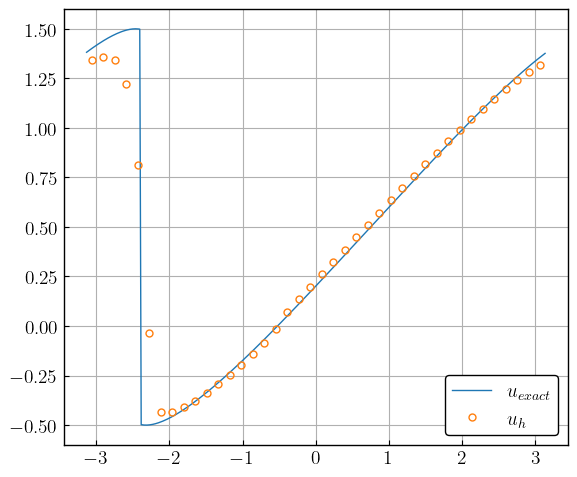

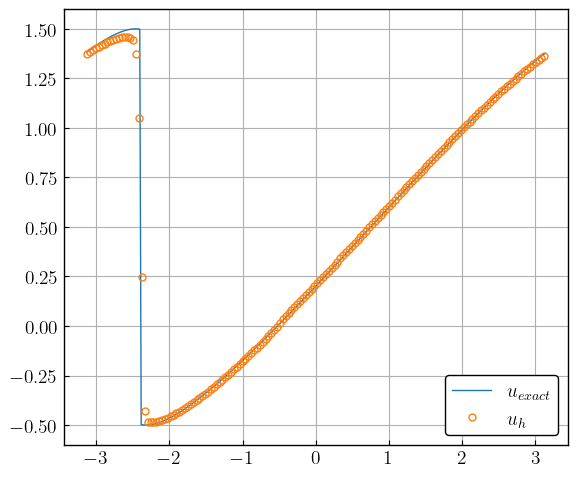

In [42]:
# DG P0
config = {
    "k": 0,
    "init": burgers_init,
    "exact": burgers_exact,
    "xleft": -np.pi,
    "xright": np.pi,
    "f": burgers_f,
    "df": burgers_df,
    "fhat": get_LF_flux(burgers_f, burgers_get_alpha),
}

print("=== DG P0: Convergence Test (t=0.5) ===")
order_test(tend=0.5, nlist=np.array([20, 40, 80, 160, 320]), **config)
print("\n=== DG P0: Shock Test (t=1.5) ===")
shock_test(tend=1.5, nlist=np.array([40, 160]), n_ref=320, **config)

### Test 2: DG P1

=== DG P1: Convergence Test (t=0.5) ===
  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 20  2.35e-02       NaN  1.48e-02       NaN    3.07e-02         NaN
 40  6.03e-03  1.96e+00  3.95e-03  1.91e+00    9.02e-03    1.77e+00
 80  1.53e-03  1.98e+00  1.04e-03  1.93e+00    2.41e-03    1.90e+00
160  3.89e-04  1.98e+00  2.68e-04  1.95e+00    6.26e-04    1.94e+00
320  9.86e-05  1.98e+00  6.84e-05  1.97e+00    1.59e-04    1.98e+00

=== DG P1: Shock Test (t=1.5) ===


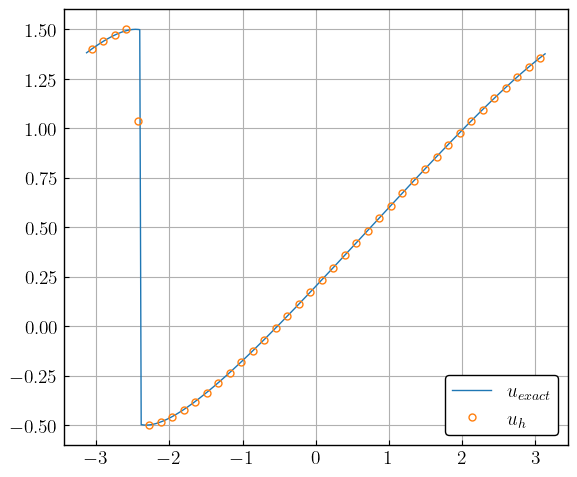

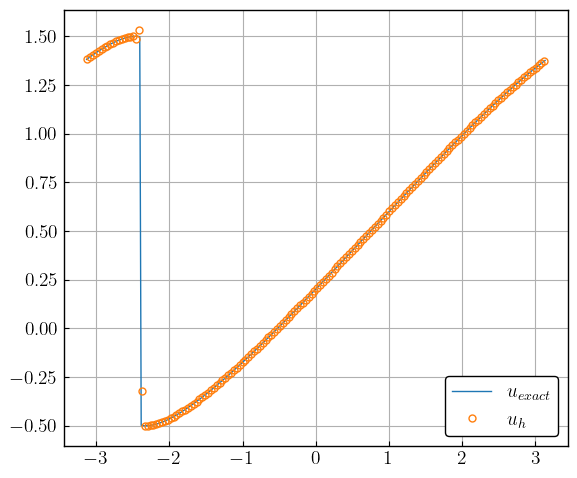

In [43]:
# DG P1
config = {
    "k": 1,
    "init": burgers_init,
    "exact": burgers_exact,
    "xleft": -np.pi,
    "xright": np.pi,
    "f": burgers_f,
    "df": burgers_df,
    "fhat": get_LF_flux(burgers_f, burgers_get_alpha),
}

print("=== DG P1: Convergence Test (t=0.5) ===")
order_test(tend=0.5, nlist=np.array([20, 40, 80, 160, 320]), **config)
print("\n=== DG P1: Shock Test (t=1.5) ===")
shock_test(tend=1.5, nlist=np.array([40, 160]), n_ref=320, **config)

### Test 3: DG P2

=== DG P2: Convergence Test (t=0.5) ===
  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 20  1.26e-03       NaN  1.02e-03       NaN    3.59e-03         NaN
 40  1.63e-04  2.95e+00  1.41e-04  2.86e+00    5.75e-04    2.64e+00
 80  2.08e-05  2.98e+00  1.89e-05  2.90e+00    8.23e-05    2.81e+00
160  2.63e-06  2.98e+00  2.47e-06  2.94e+00    1.13e-05    2.86e+00
320  3.32e-07  2.99e+00  3.16e-07  2.96e+00    1.49e-06    2.92e+00

=== DG P2: Shock Test (t=1.5) ===


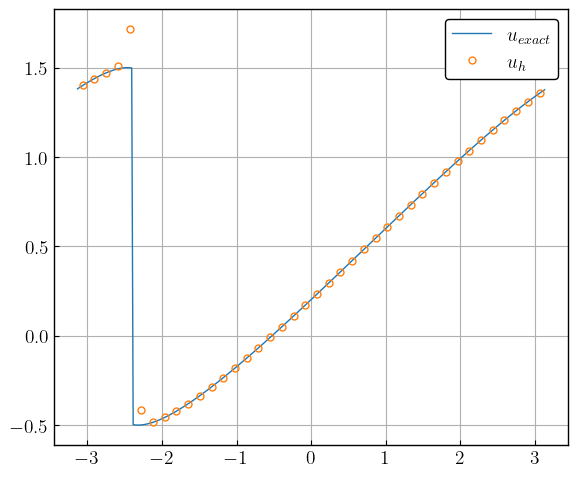

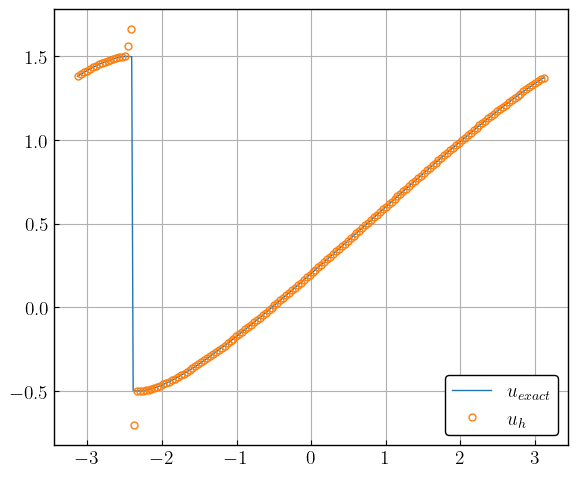

In [44]:
# DG P2
config = {
    "k": 2,
    "init": burgers_init,
    "exact": burgers_exact,
    "xleft": -np.pi,
    "xright": np.pi,
    "f": burgers_f,
    "df": burgers_df,
    "fhat": get_LF_flux(burgers_f, burgers_get_alpha),
}

print("=== DG P2: Convergence Test (t=0.5) ===")
order_test(tend=0.5, nlist=np.array([20, 40, 80, 160, 320]), **config)
print("\n=== DG P2: Shock Test (t=1.5) ===")
shock_test(tend=1.5, nlist=np.array([40, 160]), n_ref=320, **config)

### Test 4: DG P2 with TVD Limiter

=== DG P2 + TVD: Convergence Test (t=0.5) ===
  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 20  7.93e-02       NaN  5.23e-02       NaN    5.80e-02         NaN
 40  1.94e-02  2.03e+00  1.64e-02  1.68e+00    2.32e-02    1.32e+00
 80  4.30e-03  2.17e+00  4.63e-03  1.82e+00    8.28e-03    1.49e+00
160  9.08e-04  2.24e+00  1.28e-03  1.85e+00    3.09e-03    1.42e+00
320  1.86e-04  2.29e+00  3.47e-04  1.89e+00    1.13e-03    1.46e+00

=== DG P2 + TVD: Shock Test (t=1.5) ===


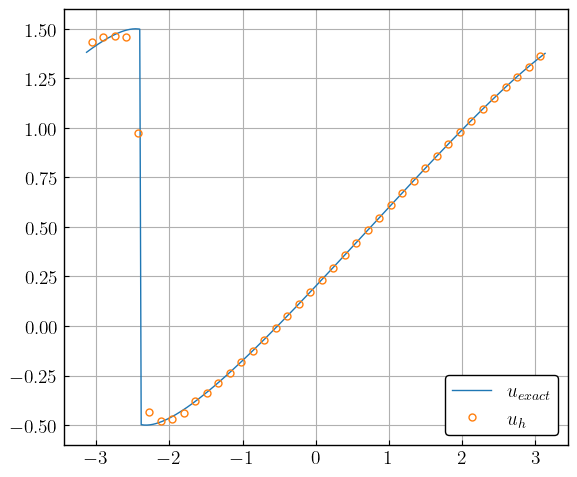

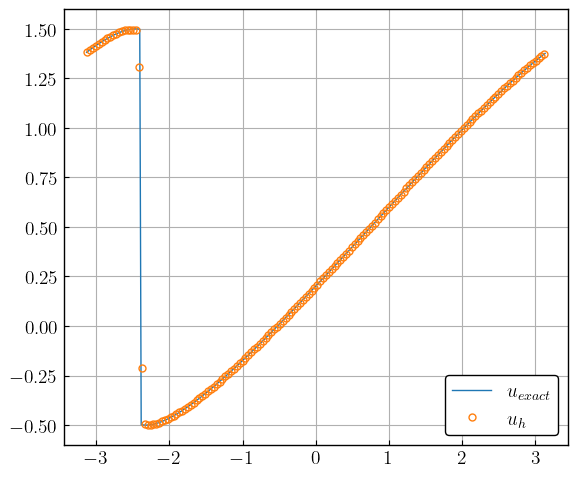

In [45]:
# DG P2 + TVD limiter
config = {
    "k": 2,
    "init": burgers_init,
    "exact": burgers_exact,
    "xleft": -np.pi,
    "xright": np.pi,
    "f": burgers_f,
    "df": burgers_df,
    "fhat": get_LF_flux(burgers_f, burgers_get_alpha),
    "lim": tvd(),
}

print("=== DG P2 + TVD: Convergence Test (t=0.5) ===")
order_test(tend=0.5, nlist=np.array([20, 40, 80, 160, 320]), **config)
print("\n=== DG P2 + TVD: Shock Test (t=1.5) ===")
shock_test(tend=1.5, nlist=np.array([40, 160]), n_ref=320, **config)

### Test 5: DG P2 with TVB Limiter (M=5)

=== DG P2 + TVB (M=5): Convergence Test (t=0.5) ===
  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 20  1.26e-03       NaN  1.02e-03       NaN    3.59e-03         NaN
 40  1.63e-04  2.95e+00  1.41e-04  2.86e+00    5.75e-04    2.64e+00
 80  2.08e-05  2.98e+00  1.89e-05  2.90e+00    8.23e-05    2.81e+00
160  2.63e-06  2.98e+00  2.47e-06  2.94e+00    1.13e-05    2.86e+00
320  3.32e-07  2.99e+00  3.16e-07  2.96e+00    1.49e-06    2.92e+00

=== DG P2 + TVB (M=5): Shock Test (t=1.5) ===


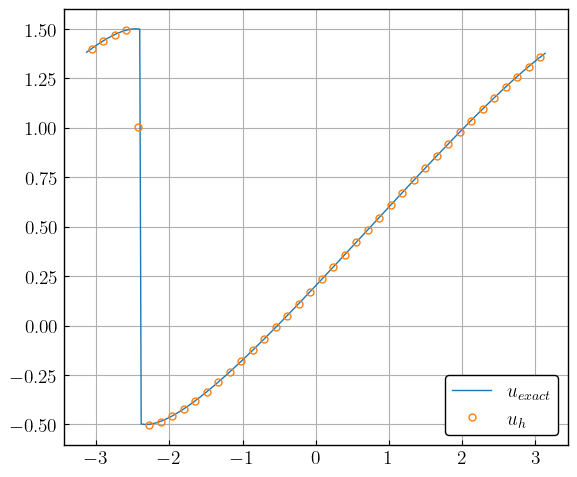

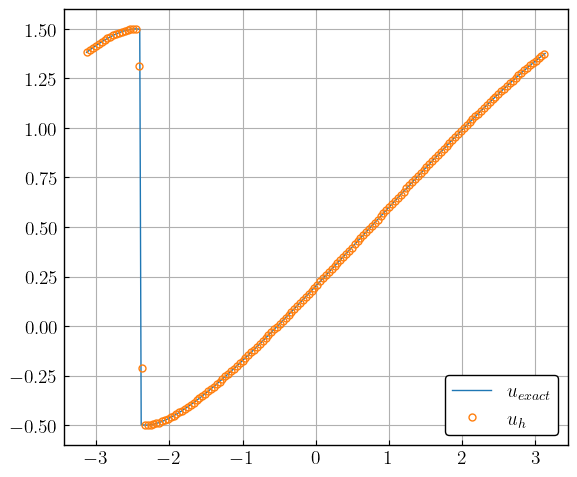

In [46]:
# DG P2 + TVB limiter (M=5)
config = {
    "k": 2,
    "init": burgers_init,
    "exact": burgers_exact,
    "xleft": -np.pi,
    "xright": np.pi,
    "f": burgers_f,
    "df": burgers_df,
    "fhat": get_LF_flux(burgers_f, burgers_get_alpha),
    "lim": tvb(5),
}

print("=== DG P2 + TVB (M=5): Convergence Test (t=0.5) ===")
order_test(tend=0.5, nlist=np.array([20, 40, 80, 160, 320]), **config)
print("\n=== DG P2 + TVB (M=5): Shock Test (t=1.5) ===")
shock_test(tend=1.5, nlist=np.array([40, 160]), n_ref=320, **config)